# 📈 Sales Forecasting System

## Project Overview

This project analyzes historical store sales data and uses machine learning to predict future sales.

The project covers:
- Data collection and loading
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Time-based feature engineering
- Machine learning model development
- Sales prediction
- Model evaluation using MAE and RMSE
- Actual vs. predicted sales comparison
- Future sales forecasting

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [116]:
# Load datasets

train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [117]:
# Display dataset dimensions

print("Train dataset shape:", train.shape)
print("Stores dataset shape:", stores.shape)

Train dataset shape: (3000888, 6)
Stores dataset shape: (54, 5)


In [118]:
# Display the first five rows

print("Train Dataset:")
display(train.head())

print("\nStores Dataset:")
display(stores.head())

Train Dataset:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



Stores Dataset:


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [119]:
# Display column names

print("Train columns:")
print(train.columns.tolist())

print("\nStores columns:")
print(stores.columns.tolist())

Train columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

Stores columns:
['store_nbr', 'city', 'state', 'type', 'cluster']


In [120]:
# Check data types
print("Train Dataset Data Types:")
print(train.dtypes)

print("\nStores Dataset Data Types:")
print(stores.dtypes)

Train Dataset Data Types:
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

Stores Dataset Data Types:
store_nbr     int64
city         object
state        object
type         object
cluster       int64
dtype: object


In [121]:
# Check for missing values

print("Missing values in Train Dataset:")
print(train.isnull().sum())

print("\nMissing values in Stores Dataset:")
print(stores.isnull().sum())

Missing values in Train Dataset:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Missing values in Stores Dataset:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64


In [122]:
# Check duplicate rows

print("Duplicate rows in Train Dataset:", train.duplicated().sum())
print("Duplicate rows in Stores Dataset:", stores.duplicated().sum())

Duplicate rows in Train Dataset: 0
Duplicate rows in Stores Dataset: 0


In [123]:
# Basic statistical summary

print("Train Dataset Summary:")
display(train.describe())

print("\nStores Dataset Summary:")
display(stores.describe(include="all"))

Train Dataset Summary:


,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02



Stores Dataset Summary:


,store_nbr,city,state,type,cluster
count,54.000000,54,54,54,54.000000
unique,NaN,22,16,5,NaN
top,NaN,Quito,Pichincha,D,NaN
freq,NaN,18,19,18,NaN
mean,27.500000,NaN,NaN,NaN,8.481481
std,15.732133,NaN,NaN,NaN,4.693395
min,1.000000,NaN,NaN,NaN,1.000000
25%,14.250000,NaN,NaN,NaN,4.000000
50%,27.500000,NaN,NaN,NaN,8.500000
75%,40.750000,NaN,NaN,NaN,13.000000


In [124]:
# Check date range

print("First date:", train["date"].min())
print("Last date:", train["date"].max())

First date: 2013-01-01
Last date: 2017-08-15


In [125]:
# Check number of unique values

print("Number of stores:", train["store_nbr"].nunique())
print("Number of product families:", train["family"].nunique())

print("\nProduct families:")
print(train["family"].unique())

Number of stores: 54
Number of product families: 33

Product families:
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [126]:
# Create a copy of the original dataset
sales_data = train.copy()

# Convert date column to datetime
sales_data["date"] = pd.to_datetime(sales_data["date"])

print("Date column converted successfully!")
print(sales_data.dtypes)

Date column converted successfully!
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object


In [127]:
# Verify date range after conversion

print("First date:", sales_data["date"].min())
print("Last date:", sales_data["date"].max())

print("\nDate column type:", sales_data["date"].dtype)

First date: 2013-01-01 00:00:00
Last date: 2017-08-15 00:00:00

Date column type: datetime64[ns]


In [128]:
# Check sales values

print("Minimum sales:", sales_data["sales"].min())
print("Maximum sales:", sales_data["sales"].max())
print("Negative sales values:", (sales_data["sales"] < 0).sum())

Minimum sales: 0.0
Maximum sales: 124717.0
Negative sales values: 0


In [129]:
# Check whether all store IDs in sales data exist in the stores dataset

missing_stores = set(sales_data["store_nbr"]) - set(stores["store_nbr"])

print("Store IDs missing from stores dataset:", missing_stores)

Store IDs missing from stores dataset: set()


In [130]:
# Final data quality check

print("===== FINAL DATA QUALITY CHECK =====")

print("Rows:", len(sales_data))
print("Columns:", len(sales_data.columns))

print("\nMissing values:")
print(sales_data.isnull().sum())

print("\nDuplicate rows:", sales_data.duplicated().sum())

print("\nData types:")
print(sales_data.dtypes)

===== FINAL DATA QUALITY CHECK =====
Rows: 3000888
Columns: 6

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Duplicate rows: 0

Data types:
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object


In [131]:
# Aggregate sales by date

daily_sales = (
    sales_data
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [132]:
print("Number of days:", len(daily_sales))
print("Date range:", daily_sales["date"].min(), "to", daily_sales["date"].max())

Number of days: 1684
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


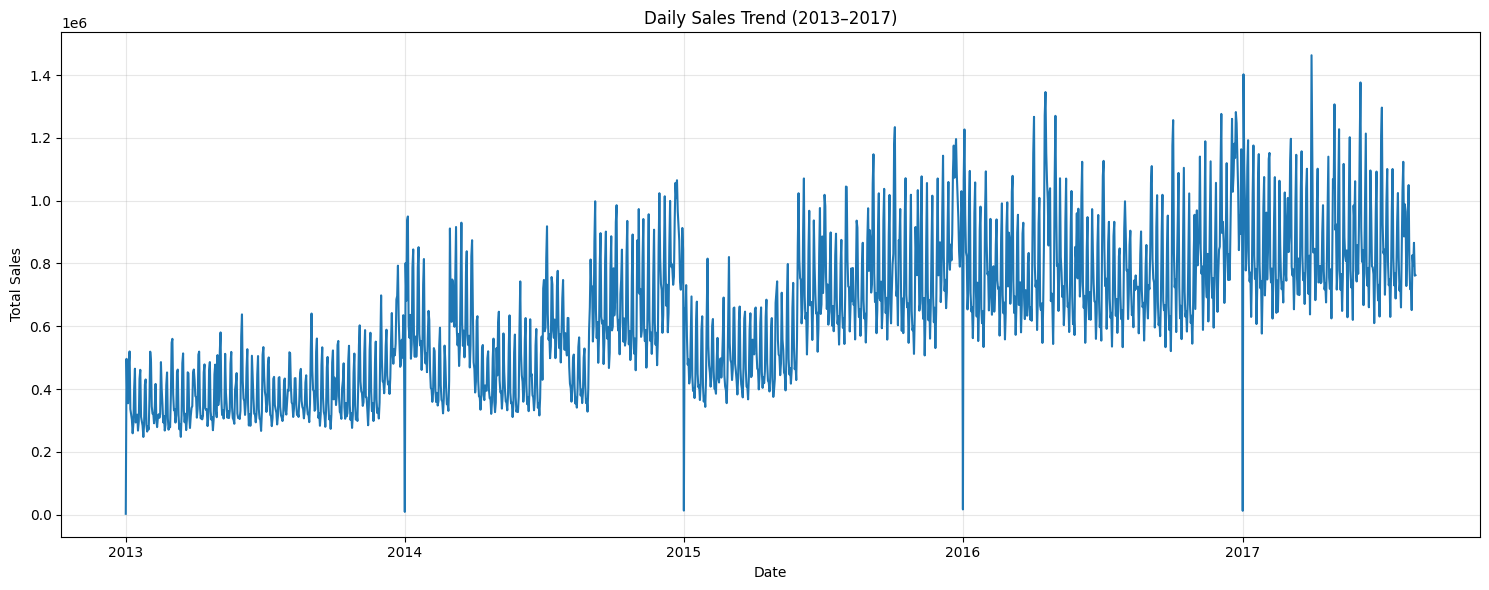

In [133]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Daily Sales Trend (2013–2017)")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [134]:
# Extract year and month for analysis

daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month"] = daily_sales["date"].dt.month

daily_sales.head()

,date,sales,year,month
0,2013-01-01,2511.618999,2013,1
1,2013-01-02,496092.417944,2013,1
2,2013-01-03,361461.231124,2013,1
3,2013-01-04,354459.677093,2013,1
4,2013-01-05,477350.121229,2013,1


In [135]:
monthly_sales = (
    daily_sales
    .groupby(["year", "month"])["sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,year,month,sales
0,2013,1,1.032762e+07
1,2013,2,9.658960e+06
2,2013,3,1.142850e+07
3,2013,4,1.099346e+07
4,2013,5,1.159770e+07


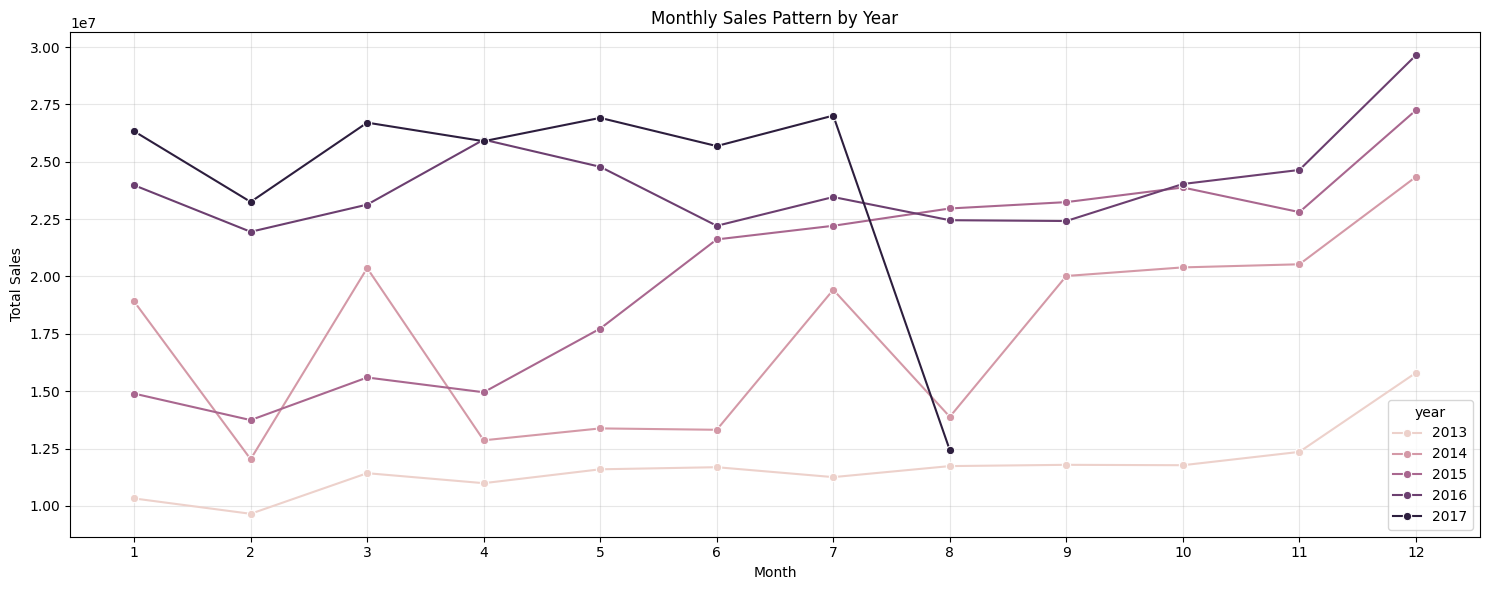

In [136]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="sales",
    hue="year",
    marker="o"
)

plt.title("Monthly Sales Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [137]:
# Find the highest and lowest sales months

highest_month = monthly_sales.loc[monthly_sales["sales"].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales["sales"].idxmin()]

print("Highest sales month:")
print(f"Year: {highest_month['year']}, Month: {highest_month['month']}")
print(f"Sales: {highest_month['sales']:,.2f}")

print("\nLowest sales month:")
print(f"Year: {lowest_month['year']}, Month: {lowest_month['month']}")
print(f"Sales: {lowest_month['sales']:,.2f}")

Highest sales month:
Year: 2016.0, Month: 12.0
Sales: 29,640,287.58

Lowest sales month:
Year: 2013.0, Month: 2.0
Sales: 9,658,959.78


In [138]:
# Average sales for each calendar month across all years

seasonal_sales = (
    monthly_sales
    .groupby("month")["sales"]
    .mean()
    .reset_index()
)

print(seasonal_sales)

    month         sales
0       1  1.888843e+07
1       2  1.612745e+07
2       3  1.944570e+07
3       4  1.813362e+07
4       5  1.887983e+07
5       6  1.890334e+07
6       7  2.067261e+07
7       8  1.669448e+07
8       9  1.936842e+07
9      10  2.002009e+07
10     11  2.008395e+07
11     12  2.425696e+07


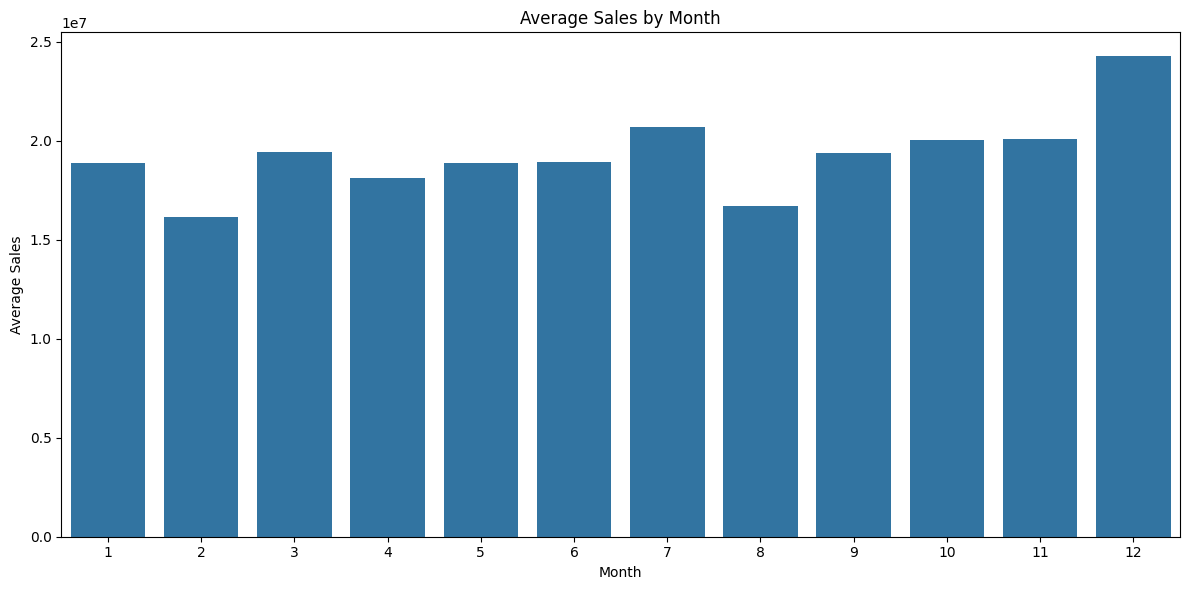

In [139]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=seasonal_sales,
    x="month",
    y="sales"
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

In [140]:
# Create daily total sales dataset for forecasting

forecast_data = (
    sales_data
    .groupby("date")["sales"]
    .sum()
    .reset_index()
    .sort_values("date")
)

forecast_data.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [141]:
print("Forecasting dataset shape:", forecast_data.shape)
print("First date:", forecast_data["date"].min())
print("Last date:", forecast_data["date"].max())

Forecasting dataset shape: (1684, 2)
First date: 2013-01-01 00:00:00
Last date: 2017-08-15 00:00:00


In [142]:
# Extract time-based features

forecast_data["year"] = forecast_data["date"].dt.year
forecast_data["month"] = forecast_data["date"].dt.month
forecast_data["day"] = forecast_data["date"].dt.day
forecast_data["day_of_week"] = forecast_data["date"].dt.dayofweek
forecast_data["week_of_year"] = forecast_data["date"].dt.isocalendar().week.astype(int)

display(forecast_data.head())

,date,sales,year,month,day,day_of_week,week_of_year
0,2013-01-01,2511.618999,2013,1,1,1,1
1,2013-01-02,496092.417944,2013,1,2,2,1
2,2013-01-03,361461.231124,2013,1,3,3,1
3,2013-01-04,354459.677093,2013,1,4,4,1
4,2013-01-05,477350.121229,2013,1,5,5,1


In [143]:
# Define features and target

features = [
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year"
]

target = "sales"

X = forecast_data[features]
y = forecast_data[target]

print("Features:")
print(features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Features:
['year', 'month', 'day', 'day_of_week', 'week_of_year']

Feature matrix shape: (1684, 5)
Target shape: (1684,)


In [144]:
# Chronological train-test split

split_index = int(len(forecast_data) * 0.8)

train_data = forecast_data.iloc[:split_index]
test_data = forecast_data.iloc[split_index:]

print("Training period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting period:")
print(test_data["date"].min(), "to", test_data["date"].max())

print("\nTraining rows:", len(train_data))
print("Testing rows:", len(test_data))

Training period:
2013-01-01 00:00:00 to 2016-09-11 00:00:00

Testing period:
2016-09-12 00:00:00 to 2017-08-15 00:00:00

Training rows: 1347
Testing rows: 337


In [145]:
# Prepare training and testing features and targets

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1347, 5)
y_train: (1347,)
X_test: (337, 5)
y_test: (337,)


In [146]:
# Create and train Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [147]:
# Predict sales for the test period

y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[699443.98036139 674566.14118589 699741.14507998 571835.10332561
 680371.24858456 903739.00015095 971737.07811347 736518.32665144
 684994.85329396 694703.68238006]


In [148]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 124,542.65


In [149]:
# Calculate Root Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

Root Mean Squared Error (RMSE): 174,997.58


In [150]:
# Create actual vs predicted comparison

results = pd.DataFrame({
    "Date": test_data["date"].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results["Error"] = results["Actual Sales"] - results["Predicted Sales"]

display(results.head(10))

,Date,Actual Sales,Predicted Sales,Error
0,2016-09-12,6.787765e+05,699443.980361,-20667.521235
1,2016-09-13,6.034279e+05,674566.141186,-71138.194212
2,2016-09-14,6.242621e+05,699741.145080,-75479.073104
3,2016-09-15,5.683248e+05,571835.103326,-3510.290340
4,2016-09-16,6.919126e+05,680371.248585,11541.352881
5,2016-09-17,8.992193e+05,903739.000151,-4519.702643
6,2016-09-18,1.018663e+06,971737.078113,46925.579281
7,2016-09-19,6.811593e+05,736518.326651,-55358.984675
8,2016-09-20,6.509803e+05,684994.853294,-34014.531322
9,2016-09-21,6.669284e+05,694703.682380,-27775.282367


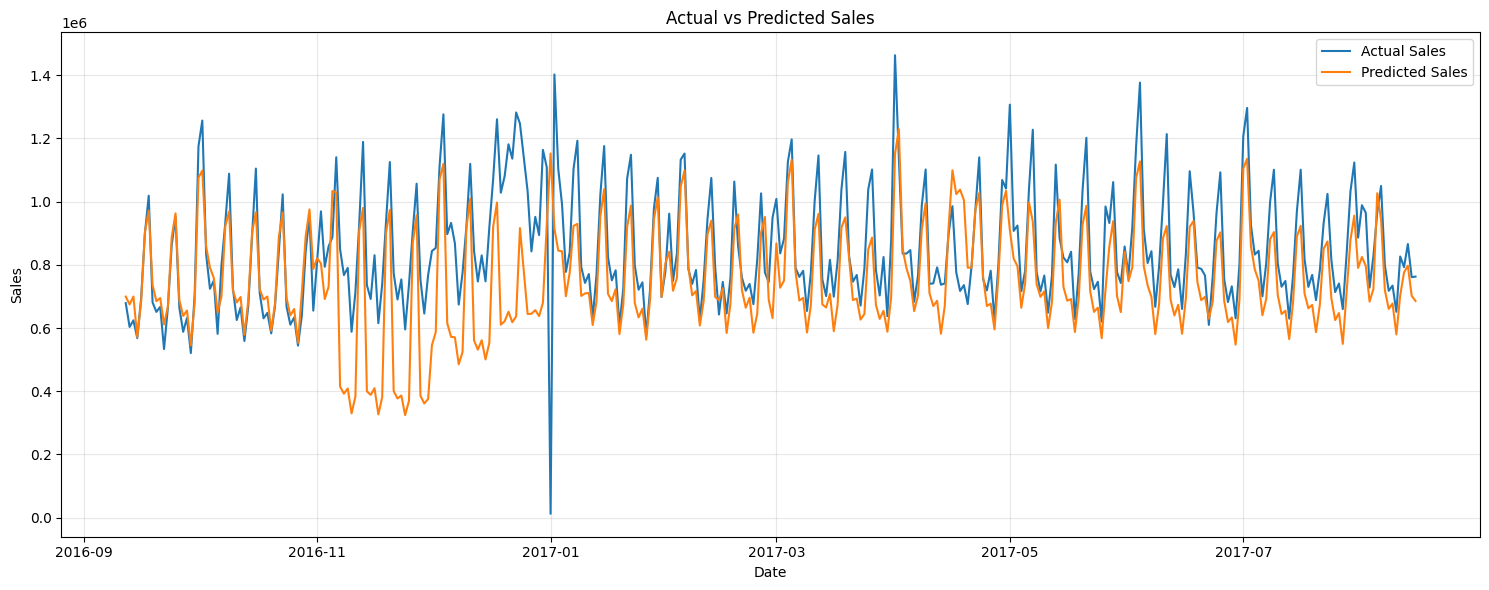

In [151]:
# Plot actual vs predicted sales

plt.figure(figsize=(15, 6))

plt.plot(
    results["Date"],
    results["Actual Sales"],
    label="Actual Sales"
)

plt.plot(
    results["Date"],
    results["Predicted Sales"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [152]:
# Compare actual and predicted sales

display(results.head(15))

,Date,Actual Sales,Predicted Sales,Error
0,2016-09-12,6.787765e+05,699443.980361,-20667.521235
1,2016-09-13,6.034279e+05,674566.141186,-71138.194212
2,2016-09-14,6.242621e+05,699741.145080,-75479.073104
3,2016-09-15,5.683248e+05,571835.103326,-3510.290340
4,2016-09-16,6.919126e+05,680371.248585,11541.352881
5,2016-09-17,8.992193e+05,903739.000151,-4519.702643
6,2016-09-18,1.018663e+06,971737.078113,46925.579281
7,2016-09-19,6.811593e+05,736518.326651,-55358.984675
8,2016-09-20,6.509803e+05,684994.853294,-34014.531322
9,2016-09-21,6.669284e+05,694703.682380,-27775.282367


In [153]:
# Train final model using all available historical data

X_full = forecast_data[features]
y_full = forecast_data[target]

final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full)

print("Final model trained on all historical data.")

Final model trained on all historical data.


In [154]:
# Create dates for the next 30 days

last_date = forecast_data["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_forecast = pd.DataFrame({
    "date": future_dates
})

print("Forecast period:")
print(future_forecast["date"].min())
print("to")
print(future_forecast["date"].max())

Forecast period:
2017-08-16 00:00:00
to
2017-09-14 00:00:00


In [155]:
# Prepare historical sales for recursive forecasting

historical_sales = forecast_data[["date", "sales"]].copy()

future_predictions = []

for current_date in future_dates:

    # Create time-based features
    year = current_date.year
    month = current_date.month
    day = current_date.day
    day_of_week = current_date.dayofweek
    week_of_year = current_date.isocalendar().week



    # Create feature row
    feature_row = pd.DataFrame([{
        "year": year,
        "month": month,
        "day": day,
        "day_of_week": day_of_week,
        "week_of_year": int(week_of_year)
    }])

    # Predict sales
    prediction = final_model.predict(feature_row)[0]

    # Store prediction
    future_predictions.append(prediction)

    # Add prediction to historical sales
    historical_sales = pd.concat([
        historical_sales,
        pd.DataFrame({
            "date": [current_date],
            "sales": [prediction]
        })
    ], ignore_index=True)

In [156]:
# Create final future forecast table

future_forecast["Predicted Sales"] = future_predictions

display(future_forecast)

,date,Predicted Sales
0,2017-08-16,7.578030e+05
1,2017-08-17,6.578773e+05
2,2017-08-18,8.144476e+05
3,2017-08-19,8.700789e+05
4,2017-08-20,9.360677e+05
5,2017-08-21,7.972498e+05
6,2017-08-22,7.432054e+05
7,2017-08-23,7.465686e+05
8,2017-08-24,6.510557e+05
9,2017-08-25,8.260456e+05


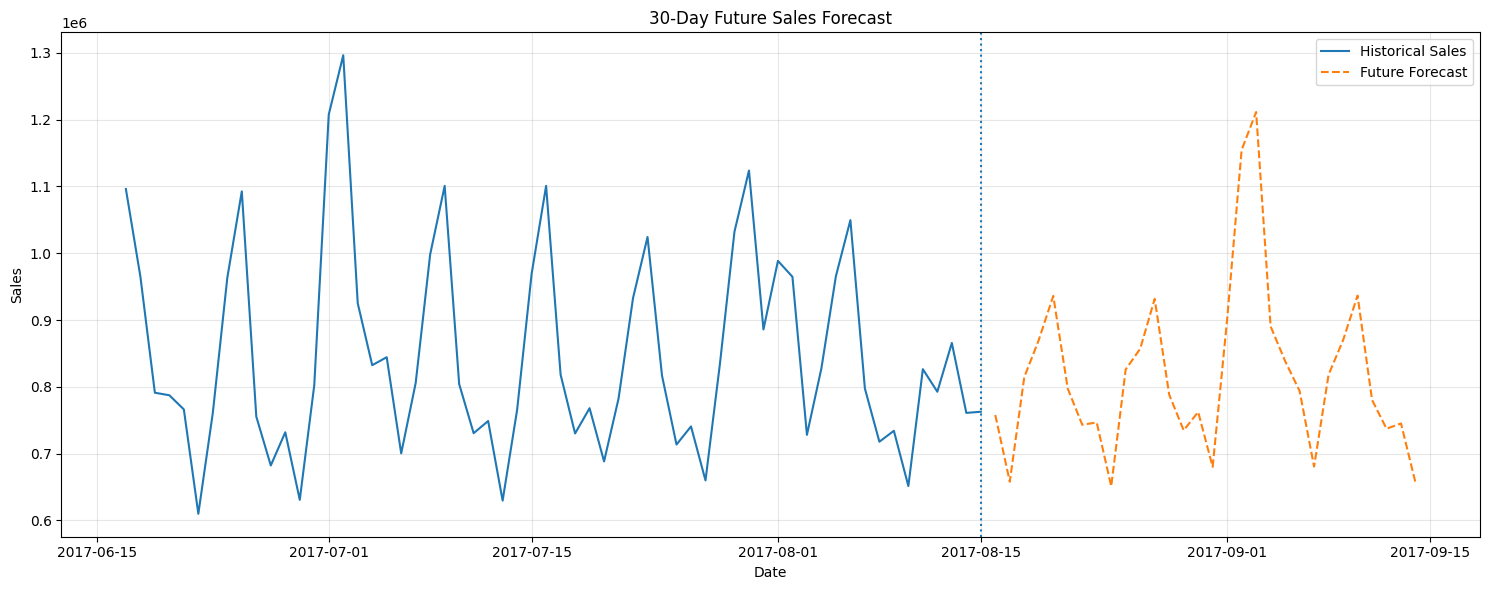

In [157]:
# Plot future sales forecast

plt.figure(figsize=(15, 6))

# Recent historical sales
recent_history = forecast_data.tail(60)

plt.plot(
    recent_history["date"],
    recent_history["sales"],
    label="Historical Sales"
)

# Future predictions
plt.plot(
    future_forecast["date"],
    future_forecast["Predicted Sales"],
    label="Future Forecast",
    linestyle="--"
)

plt.axvline(
    x=last_date,
    linestyle=":"
)

plt.title("30-Day Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [158]:
# Forecast summary

print("===== 30-DAY SALES FORECAST SUMMARY =====")

print(f"Average predicted daily sales: {future_forecast['Predicted Sales'].mean():,.2f}")
print(f"Highest predicted sales: {future_forecast['Predicted Sales'].max():,.2f}")
print(f"Lowest predicted sales: {future_forecast['Predicted Sales'].min():,.2f}")
print(f"Total predicted sales for 30 days: {future_forecast['Predicted Sales'].sum():,.2f}")

===== 30-DAY SALES FORECAST SUMMARY =====
Average predicted daily sales: 818,949.93
Highest predicted sales: 1,211,396.28
Lowest predicted sales: 651,055.71
Total predicted sales for 30 days: 24,568,497.80


In [159]:
# Create future forecast summary

forecast_summary = pd.DataFrame({
    "Metric": [
        "Forecast Period",
        "Average Predicted Daily Sales",
        "Highest Predicted Sales",
        "Lowest Predicted Sales",
        "Total Predicted Sales (30 Days)"
    ],
    "Value": [
        f"{future_forecast['date'].min().date()} to {future_forecast['date'].max().date()}",
        f"{future_forecast['Predicted Sales'].mean():,.2f}",
        f"{future_forecast['Predicted Sales'].max():,.2f}",
        f"{future_forecast['Predicted Sales'].min():,.2f}",
        f"{future_forecast['Predicted Sales'].sum():,.2f}"
    ]
})

display(forecast_summary)

,Metric,Value
0,Forecast Period,2017-08-16 to 2017-09-14
1,Average Predicted Daily Sales,"818,949.93"
2,Highest Predicted Sales,"1,211,396.28"
3,Lowest Predicted Sales,"651,055.71"
4,Total Predicted Sales (30 Days),"24,568,497.80"
